In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from src.curves.discount_curve import DiscountCurve
from src.curves.curve_shocks import CurveShocks

from src.instruments.fixed_rate_loan import FixedRateLoan
from src.instruments.floating_rate_loan import FloatingRateLoan
from src.instruments.interest_rate_swap import IRSwap

from src.risk.eve_engine import EVEEngine
from src.risk.nii_engine import NIIEngine
from src.risk.key_rate_dv01 import KeyRateDV01

from src.behavioral.nmd_model import NMDModel

from src.hedging.optimizer import HedgeOptimizer
from src.hedging.swaps import Hedge_Tenors

In [2]:
# convert curve into long format
def prepare_curve_for_irrbb(
        curve_df: pd.DataFrame,
        valuation_date: datetime
) -> pd.DataFrame:
    """ 
    Select closest available curve before valuation date 
    and convert historical yield curve dataset into
    single curve into long format (tenor, rate)
    """
    
    curve_df['Date'] = pd.to_datetime(curve_df['Date'])

    # step 1: keep the curve dataset before valuation date
    curve_hist = curve_df.loc[
        curve_df['Date'] <= valuation_date
    ]

    if curve_hist.empty:
        raise ValueError("No curve available before valuation date!")
    
    # step 2: pick latest available curve before valuation date
    latest_curve = curve_hist.sort_values('Date').iloc[-1].copy()

    # step 3: drop date column
    latest_curve = latest_curve.drop('Date')

    # step 4: wide into long format
    curve_long = (
            latest_curve
            .rename_axis('tenor_label')
            .reset_index(name = 'rate')
    )

    tenor_map = {
        "1M": 1/12,
        "3M": 3/12,
        "6M": 6/12,
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30
    }

    curve_long['tenor'] = curve_long['tenor_label'].map(tenor_map)
    curve_long = curve_long.loc[:, ['tenor', 'rate']].sort_values('tenor')
    curve_long = curve_long.rename(
        columns = {
            'tenor': 'tenor_years',
            'rate': 'zero_rate'
        }
    )
    curve_long['zero_rate'] = curve_long['zero_rate'].astype('float')

    return curve_long

In [3]:
# loading yield curve
zero_curve = pd.read_csv('../data/processed/yield_curve_clean.csv')

# initiate valuation date
valuation_date = datetime(2026, 3, 1)

# convert zero curve into long format
zero_curve_long = prepare_curve_for_irrbb(
    curve_df = zero_curve,
    valuation_date = valuation_date
)

zero_curve_long

,tenor_years,zero_rate
0,0.083333,0.0374
1,0.250000,0.0367
2,0.500000,0.0360
3,1.000000,0.0348
4,2.000000,0.0338
5,5.000000,0.0351
6,10.000000,0.0397
7,30.000000,0.0464


In [4]:
# initiate discount curve
base_dc = DiscountCurve(zero_curve_long)

# generate Basel shock scenarios
shock_engine = CurveShocks(zero_curve_long)
shocked_curves = shock_engine.generate_all_scenarios()

# shocked discount curves
shocked_dc = {
    name: DiscountCurve(curve)
    for name, curve in shocked_curves.items()
}

In [5]:
### bank balance sheet
# assets
fixed_loans = [
    FixedRateLoan(
        notional = 650000,
        start_date = '2026-03-01',
        maturity_date = '2041-03-01',
        fixed_rate = 0.054,
        payment_frequency = 'M' 
    ),
    FixedRateLoan(
        notional = 480000,
        start_date = '2026-03-01',
        maturity_date = '2046-03-01',
        fixed_rate = 0.057,
        payment_frequency = 'M' 
    )
]

floating_loans = [
    FloatingRateLoan(
        notional = 740000,
        spread = 0.012,
        maturity_years = 5,
        payments_per_year = 2
    ),
    FloatingRateLoan(
        notional = 360000,
        spread = 0.009,
        maturity_years = 3,
        payments_per_year = 4
    )
]

# swaps
hedge_swap = [
    IRSwap(
        notional = 1500000,
        fixed_rate = 0.035,
        maturity_years = 5,
        payments_per_year = 4
    )
]

# liabilities
nmd = NMDModel(
    balance = 2400000,
    product_type = 'retail_savings',
    core_ratio = 0.80,
    avg_life_years = 5,
    beta = 0.3 
)

In [6]:
# compute base EVE and NII metrics
eve_engine = EVEEngine(
    discount_curve = base_dc,
    valuation_date = valuation_date
)

nii_engine = NIIEngine(
    valuation_date = valuation_date
)

base_EVE = eve_engine.compute_eve_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd
)

base_NII = nii_engine.compute_nii_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    discount_curve = base_dc,
    rate_shock = 0
)

print(f"Base EVE: {float(base_EVE):.2f}")
print(f"Base NII: {float(base_NII):.2f}")

Base EVE: 485037.81
Base NII: 110951.95


In [7]:
# Basel shock simulation
results = []

for scenario, shocked_curve in shocked_dc.items():

    # EVE
    eve_engine_shocked = EVEEngine(
        discount_curve = shocked_curve,
        valuation_date = valuation_date
    )

    shocked_eve = eve_engine_shocked.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd
    )

    delta_eve = shocked_eve - base_EVE

    # NII
    rate_shock = (
        shocked_curve.curve.loc[
            shocked_curve.curve.tenor_years == 1,
            'zero_rate'
            ].values[0]
        - base_dc.curve.loc[
            base_dc.curve.tenor_years == 1,
            'zero_rate'
        ].values[0]
    ).round(4)

    shocked_nii = nii_engine.compute_nii_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        discount_curve = shocked_curve,
        rate_shock = rate_shock 
    )

    delta_nii = shocked_nii - base_NII

    results.append([
        scenario,
        round(float(delta_eve), 2),
        round(float(delta_nii), 2)
    ])

# IRRBB report table
irrbb_report = pd.DataFrame(
    results,
    columns = [
        'Scenario',
        'Delta_EVE',
        'Delta_NII'
    ]
).set_index('Scenario')

# Tier 1 capital check
tier1_capital = 600000

irrbb_report['EVE_ratio'] = irrbb_report['Delta_EVE'].abs() / tier1_capital
irrbb_report['Basel_Breach'] = irrbb_report['EVE_ratio'] > 0.15

irrbb_report

,Delta_EVE,Delta_NII,EVE_ratio,Basel_Breach
Scenario,,,,
parallel_up,-75024.69,7600.0,0.125041,False
parallel_down,104031.74,-7600.0,0.173386,True
short_up,-64348.55,9500.0,0.107248,False
short_down,83809.34,-9500.0,0.139682,False
steepener,15316.77,-3800.0,0.025528,False
flattener,-14259.44,3800.0,0.023766,False


In [8]:
# total bank dv01 proxy -> DV01 = (EVE_parallel_up - EVE_parallel_down) / (2 * parallel_shock (in decimals))
shock_up = irrbb_report.loc['parallel_up', 'Delta_EVE']
shock_down = irrbb_report.loc['parallel_down', 'Delta_EVE']

bank_DV01 = (shock_up - shock_down) / (2 * 0.02) # type: ignore # 200bps shock
print(f"Total Bank DV01: {round(bank_DV01, 0)}") # type: ignore

# compute bank key rate dv01 regarding tenor structure
kr_dv01_engine = KeyRateDV01(
    base_curve_df = base_dc.curve,
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    valuation_date = valuation_date
)

bank_key_rate_dv01 = kr_dv01_engine.compute_key_rate_dv01(
    shock_bps = 1
)

bank_key_rate_dv01

Total Bank DV01: -4476411.0


1Y    -1.335373e+05
2Y     2.321726e+06
5Y    -1.865779e+06
10Y   -3.466295e+06
20Y   -3.466295e+06
30Y   -1.055226e+06
Name: KeyRateDV01, dtype: float64

In [9]:
# initiator for optimizer class
hedge_optimizer = HedgeOptimizer(
    bank_kr_dv01_vector = bank_key_rate_dv01.values
)

optimal_notionals = hedge_optimizer.optimize() # optimum notional vector to hedge across term structure

hedge_optimizer.hedge_report(
    notionals = optimal_notionals
)


--- Recommended Hedge Trades ---

Pay Fixed      0.0017m 1Y swap
Receive Fixed   0.0145m 2Y swap
Pay Fixed      0.0047m 5Y swap
Pay Fixed      0.0043m 10Y swap
Pay Fixed      0.0022m 20Y swap
Pay Fixed      0.0004m 30Y swap


In [17]:
### Helper Functions 
# helper to interpolate zero-rate curve if hedging tenor is not found
def get_zero_rate(
        curve_df,
        target_tenor
):
    
    tenors = curve_df['tenor_years'].values
    rates = curve_df['zero_rate'].values

    # exact match 
    if target_tenor in tenors:
        return rates[tenors.tolist().index(target_tenor)]
    
    else:
        return np.interp(
            target_tenor,
            tenors,
            rates
        )

# helper to recompute BASE EVE with hedges
def compute_EVE_with_hedges(
        discount_curve,
        hedge_swaps
):
    
    eve_engine_temp = EVEEngine(
        discount_curve = discount_curve,
        valuation_date = valuation_date
    )

    # base instruments EVE + hedge IR swap
    eve_with_hedge_swaps = eve_engine_temp.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        swaps = hedge_swaps
    )

    return float(eve_with_hedge_swaps)

In [18]:
# creating IR Swap instruments from optimied hedge vector
hedge_swaps = []

for tenor, notional in zip(Hedge_Tenors, optimal_notionals):

    zero_rate = get_zero_rate(
        curve_df = base_dc.curve,
        target_tenor = tenor
    )

    hedge_swaps.append(
        IRSwap(
            notional = notional,
            fixed_rate = zero_rate,
            maturity_years = tenor,
            payments_per_year = 2 
        )
    )

print(f"Number of hedge swaps created: {len(hedge_swaps)}")

Number of hedge swaps created: 6


In [ ]:
# post-hedge IRRBB simulation
post_hedge_results = []

base_EVE_hedged = compute_EVE_with_hedges(
    discount_curve = base_dc,
    hedge_swaps = hedge_swaps
)

for scenario, shocked_curve in shocked_dc.items():

    shocked_eve_hedged = compute_EVE_with_hedges(
        discount_curve = shocked_curve,
        hedge_swaps = hedge_swaps
    )

    delta_eve_hedged = shocked_eve_hedged - base_EVE_hedged

    post_hedge_results.append([
        scenario,
        float(delta_eve_hedged)
    ])

post_hedge_report = pd.DataFrame(
    post_hedge_results,
    columns = [
        'Scenario',
        'Delta_EVE_PostHedge'
    ]
)

post_hedge_report = post_hedge_report.set_index('Scenario')
post_hedge_report

,Delta_EVE_PostHedge
Scenario,
parallel_up,-73844.273329
parallel_down,102441.048027
short_up,-63302.301806
short_down,82434.871328
steepener,15029.497207
flattener,-13993.904196


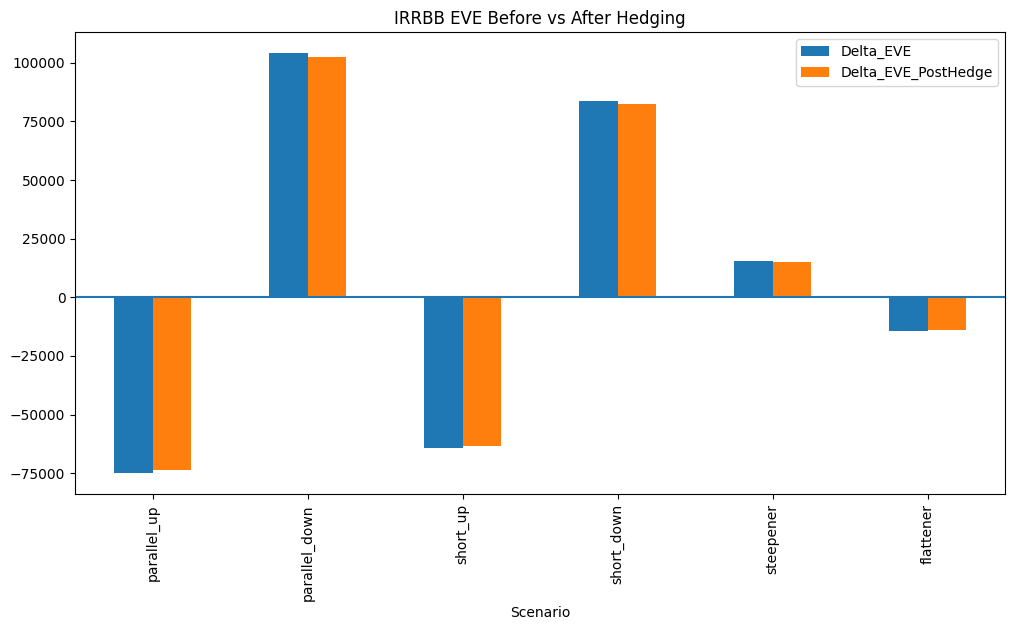

In [41]:
# comparing pre- vs post-hedge results
df_compare = irrbb_report[['Delta_EVE']].join(post_hedge_report).round(2)
df_compare['Delta_EVE_after_IRSwap_Hedge'] = (
    abs(df_compare['Delta_EVE'] - df_compare['Delta_EVE_PostHedge'])
)

#display(df_compare)

# plotting pre- vs post-hedge scenarios
fig, ax = plt.subplots(figsize = (12, 6))

df_compare[['Delta_EVE', 'Delta_EVE_PostHedge']].plot(
    kind = 'bar',
    title = 'IRRBB EVE Before vs After Hedging',
    ax = ax
)
ax.axhline(0)
plt.show()